In [1]:
# Importando a base de treinamento das casas
import pandas as pd

treino = pd.read_csv('train_house.csv')
treino

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [2]:
# Verificando quantas colunas tem, quais sao os tipos de dados de cada coluna e quantos valores nulos tem
treino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
# Visualizando quantidades de dados tem na base
treino.shape

(1460, 81)

In [4]:
# Visualizando quantos valores nulos tem em cada coluna
(treino.isna().sum()).sort_values(ascending=False)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

In [5]:
# Criando uma variavel que contenha apenas as colunas que os valores nulos ultrapassem 10% de todos os valores
eliminar = treino.columns[treino.isna().sum()/treino.shape[0] > 0.1]
eliminar

Index(['LotFrontage', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

In [6]:
# Fazendo a eliminacao dessas colunas
treino = treino.drop(eliminar,axis=1)

In [7]:
# Pegando apenas colunas de valores numericos 
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
treino = treino.select_dtypes(include=numerics)

In [8]:
# Preenchendo os valores nulos por -1
treino = treino.fillna(-1)

In [9]:
# Fazendo a separacao dos dados entre treino e teste
from sklearn.model_selection import train_test_split

X = treino.drop('SalePrice',axis=1)
y = treino.SalePrice

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [10]:
# Usando Regressao linear como modelo
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

regLR = LinearRegression().fit(X_train, y_train)
y_predLR = regLR.predict(X_test)
print(mean_absolute_error(y_test, y_predLR))
print(mean_squared_error(y_test, y_predLR))

23763.187393064778
1533982883.4448779


In [11]:
# Usando Decision Tree como modelo
from sklearn.tree import DecisionTreeRegressor

regDT = DecisionTreeRegressor(random_state=0).fit(X_train,y_train)
y_predDT = regDT.predict(X_test)
print(mean_absolute_error(y_test, y_predDT))
print(mean_squared_error(y_test, y_predDT))

27160.603734439836
2137542662.9937758


In [12]:
# Usando KNN como modelo
from sklearn.neighbors import KNeighborsRegressor

regKNN = KNeighborsRegressor(n_neighbors=2).fit(X_train, y_train)
y_predKNN = regKNN.predict(X_test)
print(mean_absolute_error(y_test, y_predKNN))
print(mean_squared_error(y_test, y_predKNN))

33273.08298755187
2733937586.841286


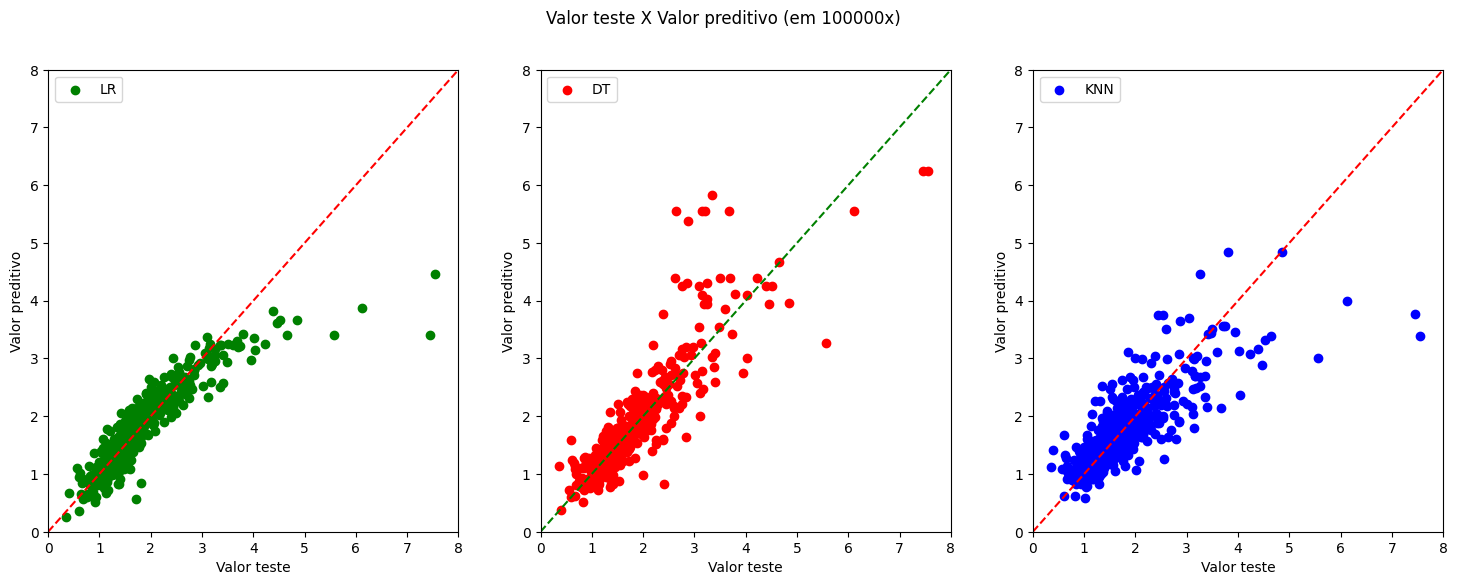

In [13]:
# Vendo os 3 modelos em um grafico
import matplotlib.pyplot as plt

fig,ax = plt.subplots(ncols=3,figsize=(18,6))

plt.suptitle('Valor teste X Valor preditivo (em 100000x)')

ax[0].scatter(y_test/100000,y_predLR/100000,label='LR',color='g') # Criando um grafico de ponto entre o valor de teste (eixo x) e o valor de treino (eixo y)
ax[0].set_xlabel('Valor teste')
ax[0].set_ylabel('Valor preditivo')
ax[0].set(xlim=(0, 8),ylim=(0,8))
ax[0].legend()
ax[0].plot([0,8],[0,8],'--r')

ax[1].scatter(y_test/100000,y_predDT/100000,label='DT',color='r')
ax[1].set_xlabel('Valor teste')
ax[1].set_ylabel('Valor preditivo')
ax[1].set(xlim=(0, 8),ylim=(0,8))
ax[1].legend()
ax[1].plot([0,8],[0,8],'--g')

ax[2].scatter(y_test/100000,y_predKNN/100000,label='KNN',color='b')
ax[2].set_xlabel('Valor teste')
ax[2].set_ylabel('Valor preditivo')
ax[2].set(xlim=(0, 8),ylim=(0,8))
ax[2].legend()
ax[2].plot([0,8],[0,8],'--r')

plt.show()

In [14]:
# Importando a base de teste e fazendo os mesmos tratamentos que fiz com a de treino para poder estarem do mesmo jeito
teste = pd.read_csv('test_house.csv')
teste = teste.drop(eliminar,axis=1)
teste = teste.select_dtypes(include=numerics)
teste = teste.fillna(-1)

In [15]:
# Usando a Regressão Linear, pois foi a que melhor performou 
y_predLR = regLR.predict(teste)
teste['SalePrice'] = y_predLR

In [16]:
# Exportando o modelo para por no kaggle
base_kaggle = teste[['Id','SalePrice']]
base_kaggle.to_csv('LR_result.csv',index=False)